# Problem 3 — Correct-target Pure GRU Baseline

## A_core_L12_H16

本 notebook 是问题 3 的正确预测对象版本：**出厂水浊度 NTU**，即题目附录中的“清水/处理后水浊度 NTU”，不是 `FILT. NTU`。

模型限制：

- 不使用 `FILT. NTU` 作为 target；
- 不使用 GRU + Persistence blend；
- 不使用 Adaptive Physics-GRU；
- 不使用 rolling prediction；
- 使用纯 Direct Multi-step GRU；
- 按时间顺序分块 train / val / test；
- 一次性输出未来 2h、4h、6h、8h、10h、12h。

本配置：

```text
FEATURE_SET_MODE = core
LOOKBACK         = 12
HIDDEN_SIZE      = 16
NUM_LAYERS       = 1
DROPOUT          = 0.0
LOSS             = SmoothL1Loss
OPTIMIZER        = AdamW
```

如果自动 target 检测错误，请在 Cell 0 手动设置：

```python
TARGET_OVERRIDE = "NTU"
```

In [1]:
# =========================
# 0. Global configuration
# =========================

from pathlib import Path

POSSIBLE_DATA_PATHS = [
    Path(r"E:\桌面\亚太杯\2026-Asia-Pacific-cup\data\merged.xlsx"),
    Path(r"E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx"),
    Path("data/merged.xlsx"),
    Path("merged.xlsx"),
    Path("../data/merged.xlsx"),
    Path("../../data/merged.xlsx"),
]

OUTPUT_DIR = Path("outputs/problem3_correct_target/gru_A_core_L12_H16")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Manual override. Keep as None unless automatic datetime detection fails.
MANUAL_DATETIME_COL = None
MANUAL_DATE_COL = "DATE"
MANUAL_TIME_COL = "TIME"

# For Problem 3, date-only data are invalid because the task requires hourly prediction.
ALLOW_DATE_ONLY = False

# Problem 3 target:
# 出厂水浊度 = 清水/处理后水浊度, i.e. the second NTU column in the statement.
# In many Excel files this column is named "NTU".
# Keep None for auto-detection. If auto-detection is wrong, set TARGET_OVERRIDE = "NTU" manually.
TARGET_OVERRIDE = None

# Feature mode:
# "core": raw water + operation + filtered water + target history
# "hrt":  core + clear well / treated water flow / tank HRT-proxy variables when available
FEATURE_SET_MODE = "core"
INCLUDE_TARGET_HISTORY = True

LOOKBACK = 12       # 12 records; each record is approximately 2 hours
HORIZON = 6          # next 2h, 4h, ..., 12h
HORIZON_HOURS = [2, 4, 6, 8, 10, 12]
EXPECTED_FREQ_HOURS = 2

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

BATCH_SIZE = 64
EPOCHS = 200
PATIENCE = 25
LEARNING_RATE = 3e-4

HIDDEN_SIZE = 16
NUM_LAYERS = 1
DROPOUT = 0.0

SEED = 42
TUNING_CONFIG_NAME = "P3_correct_target_A_core_L12_H16"

REQUESTED_DATES = ["2026-02-01", "2026-02-10", "2026-02-20"]
REQUESTED_TIMES = ["07:00", "09:00", "11:00", "13:00", "15:00", "17:00", "19:00"]

# If exact 07:00 is not on the 2-hour grid, this notebook also generates native-grid predictions.
NATIVE_GRID_START_TIME = "07:00"
NATIVE_BASE_TOLERANCE_HOURS = 1.1

# Sequence construction.
# If the strict 2-hour continuity check creates no samples, the notebook falls back to chronological row-order sequences.
USE_GAP_AWARE_SEQUENCES = True
ALLOW_ROW_ORDER_FALLBACK = True

print("Tuning config:", TUNING_CONFIG_NAME)
print("Feature mode:", FEATURE_SET_MODE)
print("Output directory:", OUTPUT_DIR.resolve())

Tuning config: P3_correct_target_A_core_L12_H16
Feature mode: core
Output directory: /Users/jinyu/workspace/2026亚太杯/codes/p3/outputs/problem3_correct_target/gru_A_core_L12_H16


In [2]:
# =========================
# 1. Imports and seed control
# =========================

import os
import math
import random
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


## 2. Load data and reconstruct datetime

这个版本会优先尝试：

```text
DATE column + TIME column
```

避免只读到日期列，导致所有时间都变成 `00:00`。

如果自动识别仍然失败，可以手动设置：

```python
MANUAL_DATE_COL = "your_date_column"
MANUAL_TIME_COL = "your_time_column"
```

或者：

```python
MANUAL_DATETIME_COL = "your_datetime_column"
```

In [3]:
# =========================
# 2. Load data and robust datetime reconstruction
# =========================

def find_data_path(possible_paths):
    for p in possible_paths:
        if p.exists():
            return p
    raise FileNotFoundError(
        "merged.xlsx not found. Please put the file at one of: "
        + ", ".join(str(p) for p in possible_paths)
    )

def parse_excel_or_regular_date(s: pd.Series) -> pd.Series:
    """
    Parse date column. Supports normal date strings/datetime and Excel serial dates.
    """
    numeric = pd.to_numeric(s, errors="coerce")
    numeric_valid = numeric.notna().mean()

    # Excel serial date is usually around 40000-50000.
    if numeric_valid >= 0.70:
        values = numeric.dropna()
        if len(values) > 0 and values.between(20000, 60000).mean() >= 0.70:
            return pd.to_datetime(numeric, unit="D", origin="1899-12-30", errors="coerce")

    return pd.to_datetime(s, errors="coerce")

def parse_time_to_timedelta(s: pd.Series) -> pd.Series:
    """
    Convert a time column into timedelta from midnight.

    Supported formats:
    - Excel time fraction, e.g. 0.2916667 = 07:00
    - Numeric hour, e.g. 7, 7.5, 14
    - HHMM integer, e.g. 700, 730, 1530
    - datetime.time or string, e.g. 07:00, 7:00:00
    """
    numeric = pd.to_numeric(s, errors="coerce")
    if numeric.notna().mean() >= 0.70:
        vals = numeric.dropna()
        if len(vals) > 0:
            min_v, max_v = vals.min(), vals.max()

            # Excel time fraction: [0, 1)
            if min_v >= 0 and max_v <= 1:
                return pd.to_timedelta(numeric, unit="D")

            # Numeric hour: [0, 24]
            if min_v >= 0 and max_v <= 24:
                return pd.to_timedelta(numeric, unit="h")

            # HHMM format, e.g. 700, 730, 1530
            if min_v >= 0 and max_v <= 2359:
                as_int = numeric.round().astype("Int64")
                hours = (as_int // 100).astype("float")
                minutes = (as_int % 100).astype("float")
                valid = (hours >= 0) & (hours <= 23) & (minutes >= 0) & (minutes <= 59)
                out = pd.Series(pd.NaT, index=s.index, dtype="timedelta64[ns]")
                out.loc[valid] = (
                    pd.to_timedelta(hours.loc[valid], unit="h") +
                    pd.to_timedelta(minutes.loc[valid], unit="m")
                )
                if out.notna().mean() >= 0.70:
                    return out

    # Object / string / datetime-like time
    text = s.astype(str).str.strip()
    parsed = pd.to_datetime(text, errors="coerce")
    out = (
        pd.to_timedelta(parsed.dt.hour, unit="h") +
        pd.to_timedelta(parsed.dt.minute, unit="m") +
        pd.to_timedelta(parsed.dt.second, unit="s")
    )
    return out

def build_datetime_column(df: pd.DataFrame):
    """
    Robust datetime reconstruction.

    Priority:
    1. Manual full datetime column.
    2. Manual date + time columns.
    3. Auto-detected date + time columns.
    4. Strong full datetime column.
    5. Fallback parseable column.
    """
    cols = list(df.columns)
    upper_map = {c: str(c).upper().strip() for c in cols}

    # 1. Manual full datetime column
    if MANUAL_DATETIME_COL is not None:
        if MANUAL_DATETIME_COL not in df.columns:
            raise KeyError(f"MANUAL_DATETIME_COL not found: {MANUAL_DATETIME_COL}")
        parsed = pd.to_datetime(df[MANUAL_DATETIME_COL], errors="coerce")
        if parsed.notna().mean() < 0.70:
            raise ValueError(f"Manual datetime column cannot be parsed: {MANUAL_DATETIME_COL}")
        return parsed, MANUAL_DATETIME_COL

    # 2. Manual DATE + TIME
    if MANUAL_DATE_COL is not None and MANUAL_TIME_COL is not None:
        if MANUAL_DATE_COL not in df.columns:
            raise KeyError(f"MANUAL_DATE_COL not found: {MANUAL_DATE_COL}")
        if MANUAL_TIME_COL not in df.columns:
            raise KeyError(f"MANUAL_TIME_COL not found: {MANUAL_TIME_COL}")
        date_part = parse_excel_or_regular_date(df[MANUAL_DATE_COL]).dt.normalize()
        time_delta = parse_time_to_timedelta(df[MANUAL_TIME_COL])
        combined = date_part + time_delta
        if combined.notna().mean() < 0.70:
            raise ValueError(f"Manual DATE + TIME cannot be parsed: {MANUAL_DATE_COL} + {MANUAL_TIME_COL}")
        return combined, f"{MANUAL_DATE_COL} + {MANUAL_TIME_COL}"

    # 3. Auto-detect DATE + TIME first
    date_keywords = ["DATE", "日期", "DAY", "日"]
    time_keywords = ["TIME", "时间", "HOUR", "小时", "时刻"]

    date_cols = [
        c for c in cols
        if any(k in upper_map[c] for k in date_keywords)
    ]
    time_cols = [
        c for c in cols
        if any(k in upper_map[c] for k in time_keywords)
    ]

    candidate_combinations = []
    for d in date_cols:
        for t in time_cols:
            if d == t:
                continue
            date_part = parse_excel_or_regular_date(df[d]).dt.normalize()
            time_delta = parse_time_to_timedelta(df[t])
            combined = date_part + time_delta
            valid_rate = combined.notna().mean()
            unique_times = combined.dropna().dt.strftime("%H:%M").nunique()
            candidate_combinations.append((valid_rate, unique_times, d, t, combined))

    # Prefer high valid rate and more than one time-of-day.
    candidate_combinations = sorted(candidate_combinations, key=lambda x: (x[0], x[1]), reverse=True)
    for valid_rate, unique_times, d, t, combined in candidate_combinations:
        if valid_rate >= 0.70 and unique_times > 1:
            return combined, f"{d} + {t}"

    # If no multi-time combination exists, still use date+time if valid.
    for valid_rate, unique_times, d, t, combined in candidate_combinations:
        if valid_rate >= 0.70:
            return combined, f"{d} + {t}"

    # 4. Strong full-datetime candidates
    strong_keywords = ["DATETIME", "DATE_TIME", "TIMESTAMP", "TIME_STAMP", "DATE/TIME", "日期时间"]
    for c in cols:
        name = upper_map[c]
        if any(k in name for k in strong_keywords):
            parsed = pd.to_datetime(df[c], errors="coerce")
            if parsed.notna().mean() >= 0.70:
                return parsed, c

    # 5. Fallback: any parseable column
    fallback_candidates = []
    for c in cols:
        parsed = pd.to_datetime(df[c], errors="coerce")
        valid_rate = parsed.notna().mean()
        if valid_rate >= 0.70:
            unique_times = parsed.dropna().dt.strftime("%H:%M").nunique()
            fallback_candidates.append((valid_rate, unique_times, c, parsed))

    fallback_candidates = sorted(fallback_candidates, key=lambda x: (x[0], x[1]), reverse=True)
    if fallback_candidates:
        valid_rate, unique_times, c, parsed = fallback_candidates[0]
        return parsed, c

    raise ValueError("Cannot detect datetime column. Please set MANUAL_DATE_COL and MANUAL_TIME_COL.")

def validate_datetime_resolution(df: pd.DataFrame, datetime_col="DATETIME"):
    dt = pd.to_datetime(df[datetime_col])
    unique_time_count = dt.dt.strftime("%H:%M").nunique()
    most_common_diffs = dt.sort_values().diff().value_counts().head(5)

    print("Unique time-of-day count:", unique_time_count)
    print("\nMost common time differences:")
    display(most_common_diffs.to_frame("count"))

    if unique_time_count <= 1 and not ALLOW_DATE_ONLY:
        print("\nDetected columns:")
        print(df.columns.tolist())
        print("\nColumns likely related to date/time:")
        for c in df.columns:
            upper = str(c).upper()
            if any(k in upper for k in ["DATE", "TIME", "HOUR", "日期", "时间", "时"]):
                print(f"\nColumn: {c}")
                display(df[[c]].head(20))

        raise ValueError(
            "DATETIME appears to be date-only: all rows have the same time-of-day. "
            "For Problem 3, you need a 2-hour timestamp. "
            "Set MANUAL_DATE_COL and MANUAL_TIME_COL in Cell 0, then rerun."
        )

data_path = find_data_path(POSSIBLE_DATA_PATHS)
print("Reading:", data_path.resolve())

data = pd.read_excel(data_path)
data.columns = [str(c).strip() for c in data.columns]

dt, dt_source = build_datetime_column(data)
data["DATETIME"] = dt

data = (
    data.dropna(subset=["DATETIME"])
        .sort_values("DATETIME")
        .drop_duplicates(subset=["DATETIME"], keep="first")
        .reset_index(drop=True)
)

print("Datetime source:", dt_source)
print("Shape:", data.shape)
print("Time range:", data["DATETIME"].min(), "to", data["DATETIME"].max())

validate_datetime_resolution(data, "DATETIME")

print("\nFirst 30 timestamps:")
display(data["DATETIME"].dt.strftime("%Y-%m-%d %H:%M").head(30))

print("\nTime-of-day distribution:")
display(data["DATETIME"].dt.strftime("%H:%M").value_counts().sort_index().to_frame("count"))

print("\nColumns:")
print(data.columns.tolist())

data.head()

Reading: /Users/jinyu/workspace/2026亚太杯/data/merged.xlsx


Datetime source: DATE + TIME
Shape: (5460, 19)
Time range: 2025-01-01 07:00:00 to 2026-04-01 05:00:00
Unique time-of-day count: 12

Most common time differences:


,count
DATETIME,
0 days 02:00:00,5459



First 30 timestamps:


0     2025-01-01 07:00
1     2025-01-01 09:00
2     2025-01-01 11:00
3     2025-01-01 13:00
4     2025-01-01 15:00
5     2025-01-01 17:00
6     2025-01-01 19:00
7     2025-01-01 21:00
8     2025-01-01 23:00
9     2025-01-02 01:00
10    2025-01-02 03:00
11    2025-01-02 05:00
12    2025-01-02 07:00
13    2025-01-02 09:00
14    2025-01-02 11:00
15    2025-01-02 13:00
16    2025-01-02 15:00
17    2025-01-02 17:00
18    2025-01-02 19:00
19    2025-01-02 21:00
20    2025-01-02 23:00
21    2025-01-03 01:00
22    2025-01-03 03:00
23    2025-01-03 05:00
24    2025-01-03 07:00
25    2025-01-03 09:00
26    2025-01-03 11:00
27    2025-01-03 13:00
28    2025-01-03 15:00
29    2025-01-03 17:00
Name: DATETIME, dtype: str


Time-of-day distribution:


,count
DATETIME,
01:00,455
03:00,455
05:00,455
07:00,455
09:00,455
11:00,455
13:00,455
15:00,455
17:00,455



Columns:
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW', 'DATETIME']


,DATE,TIME,RIVER LEVEL,R/W PUMP DUTY,R/W FLOW,R/W NTU,R/W CLR,R/W PH,FILT. NTU,C/W WELL LEVEL,PH,NTU,CLR,CL2,F/RIDE,ALUM,T/W PUMP DUTY,T/W FLOW,DATETIME
0,2025-01-01,07:00:00,6.22,1.0,45.3,150,850.0,7.0,0.04,3.82,7.2,0.12,5.0,1.5,0.0,0.04,2.0,42.6,2025-01-01 07:00:00
1,2025-01-01,09:00:00,6.34,1.0,45.2,120,830.0,7.0,0.05,3.81,7.2,0.12,5.0,1.5,0.0,0.04,2.0,42.6,2025-01-01 09:00:00
2,2025-01-01,11:00:00,6.17,1.0,44.9,82,780.0,7.0,0.05,3.81,7.2,0.12,5.0,1.6,0.0,0.04,2.0,42.7,2025-01-01 11:00:00
3,2025-01-01,13:00:00,5.99,1.0,44.9,62,720.0,7.0,0.05,3.58,7.2,0.11,5.0,1.6,0.0,0.04,2.0,42.3,2025-01-01 13:00:00
4,2025-01-01,15:00:00,5.83,1.0,44.5,56,641.0,7.0,0.05,3.58,7.2,0.11,5.0,1.6,0.0,0.04,2.0,42.5,2025-01-01 15:00:00


## 3. Basic data audit

检查必要变量是否存在、缺失值情况、时间间隔是否基本为 2 小时。

In [4]:
# =========================
# 3. Detect correct P3 target and audit data
# =========================

def _norm_col(c):
    return str(c).upper().strip().replace(" ", "").replace("_", "").replace("-", "").replace("/", "")

def detect_p3_treated_ntu_target(df: pd.DataFrame, override=None):
    """
    Detect Problem 3 target:
    出厂水浊度 NTU = 清水/处理后水浊度.

    It must NOT be:
    - R/W NTU: raw water turbidity
    - FILT. NTU: filtered water turbidity for Problem 2
    """
    cols = list(df.columns)

    if override is not None:
        if override not in df.columns:
            raise KeyError(f"TARGET_OVERRIDE not found in data columns: {override}")
        return override

    # 1. Prefer explicit clear/treated/outlet/final NTU names.
    preferred_keywords = [
        "C/W NTU", "CW NTU", "CLEAR WATER NTU", "CLEAR_WATER_NTU",
        "TREATED WATER NTU", "TREATED_NTU", "TREATED NTU",
        "OUTLET NTU", "FINAL NTU", "EFFLUENT NTU",
        "出厂水浊度", "清水浊度", "处理后水浊度", "清水/处理后水浊度",
    ]
    norm_to_col = {_norm_col(c): c for c in cols}
    for key in preferred_keywords:
        nk = _norm_col(key)
        if nk in norm_to_col:
            return norm_to_col[nk]

    # 2. In many files, the clear/treated water turbidity column is simply named "NTU".
    for candidate in ["NTU", "NTU.1", "NTU_1", "NTU (第二处)", "NTU第二处"]:
        if candidate in cols:
            return candidate

    # 3. Fallback: choose an NTU-related column after FILT. NTU, excluding raw and filtered water NTU.
    ntu_cols = [
        c for c in cols
        if ("NTU" in str(c).upper() or "浊" in str(c))
        and c not in ["R/W NTU", "FILT. NTU"]
    ]

    if "FILT. NTU" in cols and ntu_cols:
        filt_idx = cols.index("FILT. NTU")
        after_filt = [c for c in ntu_cols if cols.index(c) > filt_idx]
        if after_filt:
            return after_filt[0]

    if ntu_cols:
        return ntu_cols[-1]

    raise ValueError(
        "Cannot detect Problem 3 target. Please set TARGET_OVERRIDE in Cell 0. "
        "The target should be the clear/treated/outlet water turbidity NTU column, not FILT. NTU."
    )

TARGET = detect_p3_treated_ntu_target(data, TARGET_OVERRIDE)

if TARGET == "FILT. NTU":
    raise ValueError(
        "Wrong target detected: FILT. NTU. Problem 3 requires 出厂水浊度 NTU, "
        "i.e. clear/treated/outlet water turbidity. Please set TARGET_OVERRIDE='NTU' or the correct column name."
    )

if TARGET == "R/W NTU":
    raise ValueError(
        "Wrong target detected: R/W NTU. Problem 3 requires 出厂水浊度 NTU, not raw water turbidity."
    )

print("Detected Problem 3 target column:", TARGET)

print("\nAll NTU-related columns:")
ntu_related = [c for c in data.columns if ("NTU" in str(c).upper() or "浊" in str(c))]
for c in ntu_related:
    marker = "  <-- TARGET" if c == TARGET else ""
    print(f"  {c}{marker}")

# Raw columns that may be used for features and preprocessing.
RAW_FEATURE_CANDIDATES_CORE = [
    "RIVER LEVEL",
    "R/W PUMP DUTY",
    "R/W FLOW",
    "R/W NTU",
    "R/W CLR",
    "R/W PH",
    "FILT. NTU",
    "F/RIDE",
    "ALUM",
]

RAW_FEATURE_CANDIDATES_HRT = RAW_FEATURE_CANDIDATES_CORE + [
    "C/W WELL LEVEL",
    "PH",
    "CLR",
    "CL2",
    "T/W PUMP DUTY",
    "T/W FLOW",
    "18ML LEVEL",
    "18ML FLOW",
]

if FEATURE_SET_MODE == "core":
    RAW_FEATURE_CANDIDATES = RAW_FEATURE_CANDIDATES_CORE
elif FEATURE_SET_MODE == "hrt":
    RAW_FEATURE_CANDIDATES = RAW_FEATURE_CANDIDATES_HRT
else:
    raise ValueError(f"Unknown FEATURE_SET_MODE: {FEATURE_SET_MODE}")

BASE_RAW_FEATURES = [
    c for c in RAW_FEATURE_CANDIDATES
    if c in data.columns and c != TARGET
]

RAW_NUMERIC_COLS = list(dict.fromkeys(BASE_RAW_FEATURES + [TARGET]))

missing_for_minimum = []
for c in ["R/W NTU", "R/W PH", "R/W FLOW", "FILT. NTU", TARGET]:
    if c not in data.columns:
        missing_for_minimum.append(c)

if missing_for_minimum:
    print("\nWarning: missing expected columns:", missing_for_minimum)
    print("The notebook will continue with available columns, but please check whether merged.xlsx column names are correct.")

print("\nBase raw features available:")
print(BASE_RAW_FEATURES)

# Convert numeric columns.
for c in RAW_NUMERIC_COLS:
    data[c] = pd.to_numeric(data[c], errors="coerce")

missing_report = data[RAW_NUMERIC_COLS].isna().sum().sort_values(ascending=False)
print("\nMissing values before filling:")
display(missing_report.to_frame("missing_count"))

time_diff = data["DATETIME"].diff()
gap_report = time_diff.value_counts().head(10)
print("\nMost common time differences:")
display(gap_report.to_frame("count"))

large_gaps = data.loc[time_diff > pd.Timedelta(hours=EXPECTED_FREQ_HOURS * 1.5), ["DATETIME"]].copy()
print(f"\nNumber of gaps larger than {EXPECTED_FREQ_HOURS * 1.5:.1f} hours:", len(large_gaps))
if len(large_gaps) > 0:
    display(large_gaps.head(10))

Detected Problem 3 target column: NTU

All NTU-related columns:
  R/W NTU
  FILT. NTU
  NTU  <-- TARGET

Base raw features available:
['RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'F/RIDE', 'ALUM']

Missing values before filling:


,missing_count
R/W PUMP DUTY,1728
R/W PH,1644
ALUM,1644
NTU,336
RIVER LEVEL,0
R/W FLOW,0
R/W NTU,0
R/W CLR,0
FILT. NTU,0
F/RIDE,0



Most common time differences:


,count
DATETIME,
0 days 02:00:00,5459



Number of gaps larger than 3.0 hours: 0


## 4. Preprocessing and physical feature construction

构造第三题 GRU baseline 使用的物理特征：

```text
FRIDE_CLEAN = F/RIDE, if 0 < F/RIDE <= 0.01
FRIDE_CLEAN = 0,     if F/RIDE = 0 or F/RIDE > 0.01

AL_DOSE = 56.9 × ALUM + 81.0 × FRIDE_CLEAN

FRIDE_ABNORMAL = 1(F/RIDE > 0.01)
```

pH 变换先构造未标准化版本：

```text
RW_PH_10POWER = 10 ^ (R/W PH)
```

后面按时间分块后，只用训练集计算 pH 的 mean/std，生成：

```text
RW_PH_10POWER_STD
```

In [5]:
# =========================
# 4. Preprocessing and P3 feature construction
# =========================

data_pre = data.copy()

# Ensure numeric type.
for c in RAW_NUMERIC_COLS:
    data_pre[c] = pd.to_numeric(data_pre[c], errors="coerce")

# Preserve which target values were genuinely observed before any filling.
# Filled target values may be used only as historical inputs; TARGET_OBSERVED
# controls which future values are allowed to contribute to loss and metrics.
data_pre["TARGET_OBSERVED"] = data_pre[TARGET].notna()

# Use only past values for operational features. Leading gaps use a median
# calculated from the chronological training block, never future validation/test data.
pre_train_end = int(len(data_pre) * TRAIN_RATIO)
train_prefix = data_pre.iloc[:pre_train_end]

if "F/RIDE" in data_pre.columns:
    data_pre["F/RIDE"] = data_pre["F/RIDE"].fillna(0)

feature_fill_cols = [c for c in RAW_NUMERIC_COLS if c not in ["F/RIDE", TARGET]]
for c in feature_fill_cols:
    fill_value = train_prefix[c].median()
    if pd.isna(fill_value):
        fill_value = 0.0
    data_pre[c] = data_pre[c].ffill().fillna(fill_value)

# Target filling is causal and exists only to provide a continuous history tensor.
target_history_fill = train_prefix.loc[train_prefix[TARGET].notna(), TARGET].median()
if pd.isna(target_history_fill):
    raise ValueError("No observed target values are available in the training block.")
data_pre[TARGET] = data_pre[TARGET].ffill().fillna(target_history_fill)

# Chemical dosing features.
if "F/RIDE" in data_pre.columns:
    data_pre["FRIDE_CLEAN"] = data_pre["F/RIDE"].where(
        (data_pre["F/RIDE"] > 0) & (data_pre["F/RIDE"] <= 0.01),
        0.0
    )
    data_pre["FRIDE_ABNORMAL"] = (data_pre["F/RIDE"] > 0.01).astype(int)
else:
    data_pre["FRIDE_CLEAN"] = 0.0
    data_pre["FRIDE_ABNORMAL"] = 0

if "ALUM" in data_pre.columns:
    data_pre["AL_DOSE"] = 56.9 * data_pre["ALUM"] + 81.0 * data_pre["FRIDE_CLEAN"]
else:
    data_pre["AL_DOSE"] = 81.0 * data_pre["FRIDE_CLEAN"]

# Raw-water pH transform.
if "R/W PH" in data_pre.columns:
    ph_invalid_count = ((data_pre["R/W PH"] < 0) | (data_pre["R/W PH"] > 14)).sum()
    print("Invalid R/W PH count outside [0, 14]:", ph_invalid_count)
    ph_for_power = data_pre["R/W PH"].clip(lower=0, upper=14)
    data_pre["RW_PH_10POWER"] = 10.0 ** ph_for_power
else:
    data_pre["RW_PH_10POWER"] = 0.0

# HRT / storage proxy features for Problem 3.
# These are not strict physical HRT values because exact basin geometry is unknown.
# They are data-driven proxies representing storage level divided by treated/outlet flow.
eps = 1e-6

if "C/W WELL LEVEL" in data_pre.columns and "T/W FLOW" in data_pre.columns:
    data_pre["CW_HRT_PROXY"] = data_pre["C/W WELL LEVEL"] / (data_pre["T/W FLOW"].abs() + eps)
else:
    data_pre["CW_HRT_PROXY"] = 0.0

if "18ML LEVEL" in data_pre.columns and "18ML FLOW" in data_pre.columns:
    data_pre["TANK18_HRT_PROXY"] = data_pre["18ML LEVEL"] / (data_pre["18ML FLOW"].abs() + eps)
elif "18ML LEVEL" in data_pre.columns and "T/W FLOW" in data_pre.columns:
    data_pre["TANK18_HRT_PROXY"] = data_pre["18ML LEVEL"] / (data_pre["T/W FLOW"].abs() + eps)
else:
    data_pre["TANK18_HRT_PROXY"] = 0.0

if "C/W WELL LEVEL" in data_pre.columns and "18ML LEVEL" in data_pre.columns:
    data_pre["TOTAL_STORAGE_LEVEL_PROXY"] = data_pre["C/W WELL LEVEL"] + data_pre["18ML LEVEL"]
else:
    data_pre["TOTAL_STORAGE_LEVEL_PROXY"] = 0.0

# Final feature list.
ENGINEERED_FEATURES_CORE = [
    "RW_PH_10POWER",
    "AL_DOSE",
    "FRIDE_ABNORMAL",
]

ENGINEERED_FEATURES_HRT = ENGINEERED_FEATURES_CORE + [
    "CW_HRT_PROXY",
    "TANK18_HRT_PROXY",
    "TOTAL_STORAGE_LEVEL_PROXY",
]

if FEATURE_SET_MODE == "core":
    ENGINEERED_FEATURES = ENGINEERED_FEATURES_CORE
else:
    ENGINEERED_FEATURES = ENGINEERED_FEATURES_HRT

FEATURES = []
for c in BASE_RAW_FEATURES:
    if c in data_pre.columns and c != TARGET:
        FEATURES.append(c)

for c in ENGINEERED_FEATURES:
    if c in data_pre.columns and c not in FEATURES and c != TARGET:
        FEATURES.append(c)

# Historical target is allowed as input because at prediction time y_t and earlier target values are known.
if INCLUDE_TARGET_HISTORY and TARGET not in FEATURES:
    FEATURES.append(TARGET)

# Remove possible duplicates while preserving order.
FEATURES = list(dict.fromkeys(FEATURES))

print("Problem 3 target:", TARGET)
print("Feature set mode:", FEATURE_SET_MODE)
print("Number of features:", len(FEATURES))
print("Features:")
for f in FEATURES:
    print("  -", f)

check_cols = list(dict.fromkeys(RAW_NUMERIC_COLS + ENGINEERED_FEATURES + FEATURES))
print("\nMissing values after preprocessing:")
display(data_pre[check_cols].isna().sum().to_frame("missing_count"))

display(data_pre[["DATETIME", TARGET] + FEATURES].head())

Invalid R/W PH count outside [0, 14]: 0
Problem 3 target: NTU
Feature set mode: core
Number of features: 13
Features:
  - RIVER LEVEL
  - R/W PUMP DUTY
  - R/W FLOW
  - R/W NTU
  - R/W CLR
  - R/W PH
  - FILT. NTU
  - F/RIDE
  - ALUM
  - RW_PH_10POWER
  - AL_DOSE
  - FRIDE_ABNORMAL
  - NTU

Missing values after preprocessing:


,missing_count
RIVER LEVEL,0
R/W PUMP DUTY,0
R/W FLOW,0
R/W NTU,0
R/W CLR,0
R/W PH,0
FILT. NTU,0
F/RIDE,0
ALUM,0
NTU,0


,DATETIME,NTU,RIVER LEVEL,R/W PUMP DUTY,R/W FLOW,R/W NTU,R/W CLR,R/W PH,FILT. NTU,F/RIDE,ALUM,RW_PH_10POWER,AL_DOSE,FRIDE_ABNORMAL,NTU
0,2025-01-01 07:00:00,0.12,6.22,1.0,45.3,150,850.0,7.0,0.04,0.0,0.04,10000000.0,2.276,0,0.12
1,2025-01-01 09:00:00,0.12,6.34,1.0,45.2,120,830.0,7.0,0.05,0.0,0.04,10000000.0,2.276,0,0.12
2,2025-01-01 11:00:00,0.12,6.17,1.0,44.9,82,780.0,7.0,0.05,0.0,0.04,10000000.0,2.276,0,0.12
3,2025-01-01 13:00:00,0.11,5.99,1.0,44.9,62,720.0,7.0,0.05,0.0,0.04,10000000.0,2.276,0,0.11
4,2025-01-01 15:00:00,0.11,5.83,1.0,44.5,56,641.0,7.0,0.05,0.0,0.04,10000000.0,2.276,0,0.11


## 5. Chronological block split

按时间顺序分块：

- 前 70%：训练集
- 中间 15%：验证集
- 最后 15%：测试集

不 shuffle，避免未来信息泄漏。

In [6]:
# =========================
# 5. Chronological split
# =========================

n = len(data_pre)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = data_pre.iloc[:train_end].copy().reset_index(drop=True)
val_df = data_pre.iloc[train_end:val_end].copy().reset_index(drop=True)
test_df = data_pre.iloc[val_end:].copy().reset_index(drop=True)

print("Total rows:", n)
print("Train rows:", len(train_df), train_df["DATETIME"].min(), "to", train_df["DATETIME"].max())
print("Val rows:  ", len(val_df), val_df["DATETIME"].min(), "to", val_df["DATETIME"].max())
print("Test rows: ", len(test_df), test_df["DATETIME"].min(), "to", test_df["DATETIME"].max())

# Standardize transformed pH using training block only.
ph_mean = train_df["RW_PH_10POWER"].mean()
ph_std = train_df["RW_PH_10POWER"].std()

for df in [train_df, val_df, test_df]:
    df["RW_PH_10POWER_STD"] = (df["RW_PH_10POWER"] - ph_mean) / (ph_std + 1e-8)

full_df = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)

print("\npH train mean/std for 10^pH:")
print("mean =", ph_mean)
print("std  =", ph_std)

print("\nFinal FEATURES:")
print(FEATURES)
display(full_df[["DATETIME"] + FEATURES].head())

Total rows: 5460
Train rows: 3821 2025-01-01 07:00:00 to 2025-11-15 15:00:00
Val rows:   820 2025-11-15 17:00:00 to 2026-01-22 23:00:00
Test rows:  819 2026-01-23 01:00:00 to 2026-04-01 05:00:00

pH train mean/std for 10^pH:
mean = 10130678.265229171
std  = 583567.5154086379

Final FEATURES:
['RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'F/RIDE', 'ALUM', 'RW_PH_10POWER', 'AL_DOSE', 'FRIDE_ABNORMAL', 'NTU']


,DATETIME,RIVER LEVEL,R/W PUMP DUTY,R/W FLOW,R/W NTU,R/W CLR,R/W PH,FILT. NTU,F/RIDE,ALUM,RW_PH_10POWER,AL_DOSE,FRIDE_ABNORMAL,NTU
0,2025-01-01 07:00:00,6.22,1.0,45.3,150,850.0,7.0,0.04,0.0,0.04,10000000.0,2.276,0,0.12
1,2025-01-01 09:00:00,6.34,1.0,45.2,120,830.0,7.0,0.05,0.0,0.04,10000000.0,2.276,0,0.12
2,2025-01-01 11:00:00,6.17,1.0,44.9,82,780.0,7.0,0.05,0.0,0.04,10000000.0,2.276,0,0.12
3,2025-01-01 13:00:00,5.99,1.0,44.9,62,720.0,7.0,0.05,0.0,0.04,10000000.0,2.276,0,0.11
4,2025-01-01 15:00:00,5.83,1.0,44.5,56,641.0,7.0,0.05,0.0,0.04,10000000.0,2.276,0,0.11


## 6. Fit scalers using training block only

GRU 对变量尺度敏感。因此：

- `feature_scaler` 只在训练集输入特征上 fit
- `target_scaler` 只在训练集目标变量上 fit
- 验证集、测试集和指定日期预测都使用同一套训练集 scaler transform

In [7]:
# =========================
# 6. Scaling
# =========================

for c in FEATURES:
    if c not in train_df.columns:
        raise KeyError(f"Feature {c} not found. Please check preprocessing order.")

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

feature_scaler.fit(train_df[FEATURES])
observed_train_target = train_df.loc[train_df["TARGET_OBSERVED"], [TARGET]]
if len(observed_train_target) == 0:
    raise ValueError("Training block has no observed target values.")
target_scaler.fit(observed_train_target)

def scale_block(df: pd.DataFrame) -> pd.DataFrame:
    out = df[["DATETIME", "TARGET_OBSERVED"]].copy()
    out[FEATURES] = feature_scaler.transform(df[FEATURES])
    out["TARGET_SCALED"] = target_scaler.transform(df[[TARGET]]).reshape(-1)
    return out

train_scaled = scale_block(train_df)
val_scaled = scale_block(val_df)
test_scaled = scale_block(test_df)
full_scaled = scale_block(full_df)

print("Observed target counts:")
print("  train:", int(train_df["TARGET_OBSERVED"].sum()), "/", len(train_df))
print("  val:  ", int(val_df["TARGET_OBSERVED"].sum()), "/", len(val_df))
print("  test: ", int(test_df["TARGET_OBSERVED"].sum()), "/", len(test_df))
print("\\nScaled train preview:")
display(train_scaled.head())


Observed target counts:
  train: 3821 / 3821
  val:   820 / 820
  test:  483 / 819
\nScaled train preview:


,DATETIME,TARGET_OBSERVED,RIVER LEVEL,R/W PUMP DUTY,R/W FLOW,R/W NTU,R/W CLR,R/W PH,FILT. NTU,F/RIDE,ALUM,RW_PH_10POWER,AL_DOSE,FRIDE_ABNORMAL,NTU,TARGET_SCALED
0,2025-01-01 07:00:00,True,0.813399,-0.123059,-1.012748,4.569933,2.401617,-0.226322,-0.260802,-0.044129,-2.764006,-0.223959,-2.551798,-0.137598,-0.462092,-0.462092
1,2025-01-01 09:00:00,True,0.890146,-0.123059,-1.041661,3.398396,2.311098,-0.226322,-0.245276,-0.044129,-2.764006,-0.223959,-2.551798,-0.137598,-0.462092,-0.462092
2,2025-01-01 11:00:00,True,0.781421,-0.123059,-1.128402,1.914450,2.084800,-0.226322,-0.245276,-0.044129,-2.764006,-0.223959,-2.551798,-0.137598,-0.462092,-0.462092
3,2025-01-01 13:00:00,True,0.666300,-0.123059,-1.128402,1.133426,1.813243,-0.226322,-0.245276,-0.044129,-2.764006,-0.223959,-2.551798,-0.137598,-0.476489,-0.476489
4,2025-01-01 15:00:00,True,0.563970,-0.123059,-1.244056,0.899118,1.455693,-0.226322,-0.245276,-0.044129,-2.764006,-0.223959,-2.551798,-0.137598,-0.476489,-0.476489


## 7. Build GRU sequences

样本构造方式：

```text
X_t = [x_{t-11}, ..., x_t]
y_t = [FILT.NTU_{t+1}, ..., FILT.NTU_{t+6}]
```

默认优先使用 gap-aware 构造方式：如果时间缺口大于 3 小时，则不跨缺口构造序列。  
如果 strict gap-aware 构造后没有足够样本，本 notebook 会自动 fallback 到按时间排序后的 row-order 滑动窗口，确保 baseline 可以先跑通。

In [8]:
# =========================
# 7. Sequence construction
# =========================

def make_sequences(
    scaled_df: pd.DataFrame,
    features,
    target_col: str,
    lookback: int,
    horizon: int,
    gap_aware: bool,
    expected_freq_hours: int = 2,
):
    df = scaled_df.copy().reset_index(drop=True)
    df["DATETIME"] = pd.to_datetime(df["DATETIME"])

    if gap_aware:
        gaps = df["DATETIME"].diff()
        segment_id = (gaps > pd.Timedelta(hours=expected_freq_hours * 1.5)).cumsum()
    else:
        segment_id = pd.Series(np.zeros(len(df), dtype=int), index=df.index)
    df["_segment_id"] = segment_id.values

    X_list, y_list, mask_list, base_times, target_times = [], [], [], [], []

    for _, seg in df.groupby("_segment_id"):
        seg = seg.reset_index(drop=True)
        if len(seg) < lookback + horizon:
            continue

        values = seg[features].to_numpy(dtype=np.float32)
        target_values = seg[target_col].to_numpy(dtype=np.float32)
        observed = seg["TARGET_OBSERVED"].to_numpy(dtype=np.float32)
        times = pd.to_datetime(seg["DATETIME"]).to_numpy()

        for end_idx in range(lookback - 1, len(seg) - horizon):
            future_slice = slice(end_idx + 1, end_idx + 1 + horizon)
            X_list.append(values[end_idx - lookback + 1:end_idx + 1])
            y_list.append(target_values[future_slice])
            mask_list.append(observed[future_slice])
            base_times.append(times[end_idx])
            target_times.append(times[future_slice])

    if len(X_list) == 0:
        return (
            np.empty((0, lookback, len(features)), dtype=np.float32),
            np.empty((0, horizon), dtype=np.float32),
            np.empty((0, horizon), dtype=np.float32),
            np.array([]),
            np.empty((0, horizon), dtype="datetime64[ns]"),
        )

    return (
        np.stack(X_list).astype(np.float32),
        np.stack(y_list).astype(np.float32),
        np.stack(mask_list).astype(np.float32),
        np.array(base_times),
        np.stack(target_times),
    )

def build_all_sequences(gap_aware=True):
    args = (FEATURES, "TARGET_SCALED", LOOKBACK, HORIZON, gap_aware, EXPECTED_FREQ_HOURS)
    train = make_sequences(train_scaled, *args)
    val = make_sequences(val_scaled, *args)
    test = make_sequences(test_scaled, *args)
    return (*train, *val, *test)

sequence_mode = "gap_aware" if USE_GAP_AWARE_SEQUENCES else "row_order"
(
    X_train, y_train, mask_train, train_base_times, train_target_times,
    X_val, y_val, mask_val, val_base_times, val_target_times,
    X_test, y_test, mask_test, test_base_times, test_target_times,
) = build_all_sequences(USE_GAP_AWARE_SEQUENCES)

if (len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0) and ALLOW_ROW_ORDER_FALLBACK:
    print("Warning: gap-aware sequence construction produced insufficient samples.")
    print("Fallback to chronological row-order sequences.")
    sequence_mode = "row_order_fallback"
    (
        X_train, y_train, mask_train, train_base_times, train_target_times,
        X_val, y_val, mask_val, val_base_times, val_target_times,
        X_test, y_test, mask_test, test_base_times, test_target_times,
    ) = build_all_sequences(False)

print("Sequence mode:", sequence_mode)
print("X_train:", X_train.shape, "observed labels:", int(mask_train.sum()))
print("X_val:  ", X_val.shape, "observed labels:", int(mask_val.sum()))
print("X_test: ", X_test.shape, "observed labels:", int(mask_test.sum()))

if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
    raise ValueError("Not enough sequences. Check LOOKBACK/HORIZON, data size, or datetime parsing.")
if mask_train.sum() == 0 or mask_val.sum() == 0 or mask_test.sum() == 0:
    raise ValueError("At least one split has no observed target labels.")


Sequence mode: gap_aware
X_train: (3804, 12, 13) observed labels: 22824
X_val:   (803, 12, 13) observed labels: 4818
X_test:  (802, 12, 13) observed labels: 2796


## 8. PyTorch Dataset and DataLoader

In [9]:
# =========================
# 8. Dataset and DataLoader
# =========================

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, mask):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.mask[idx]

train_loader = DataLoader(
    TimeSeriesDataset(X_train, y_train, mask_train),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=False,
)
val_loader = DataLoader(
    TimeSeriesDataset(X_val, y_val, mask_val),
    batch_size=BATCH_SIZE, shuffle=False, drop_last=False,
)
test_loader = DataLoader(
    TimeSeriesDataset(X_test, y_test, mask_test),
    batch_size=BATCH_SIZE, shuffle=False, drop_last=False,
)

print("Number of train batches:", len(train_loader))
print("Number of val batches:", len(val_loader))
print("Number of test batches:", len(test_loader))


Number of train batches: 60
Number of val batches: 13
Number of test batches: 13


## 9. Pure Direct Multi-step GRU baseline

本模型是纯 GRU baseline，不包含输出端修正。

配置：

```text
FEATURE_SET_MODE = core
LOOKBACK         = 12
HIDDEN_SIZE      = 16
NUM_LAYERS       = 1
DROPOUT          = 0.0
LOSS             = SmoothL1Loss
OPTIMIZER        = AdamW
```

输入：

```text
过去 LOOKBACK 个时间点的多变量序列
```

输出：

```text
未来 2h、4h、6h、8h、10h、12h 的出厂水浊度 NTU
```

In [10]:
# =========================
# 9. GRU model
# =========================

class GRUBaseline(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_size: int = 64,
        num_layers: int = 1,
        dropout: float = 0.0,
        output_size: int = 6,
    ):
        super().__init__()

        effective_dropout = dropout if num_layers > 1 else 0.0

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=effective_dropout,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        gru_out, h_n = self.gru(x)
        last_hidden = gru_out[:, -1, :]
        out = self.fc(last_hidden)
        return out

model = GRUBaseline(
    input_size=len(FEATURES),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    output_size=HORIZON,
).to(device)

criterion = nn.SmoothL1Loss(reduction="none")
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

print(model)

GRUBaseline(
  (gru): GRU(13, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=6, bias=True)
)


## 10. Train with early stopping

以验证集 MSE 作为 early stopping 依据。

In [11]:
# =========================
# 10. Training
# =========================

def run_one_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_weighted_loss = 0.0
    total_observed = 0.0

    for xb, yb, mb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        mb = mb.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            pred = model(xb)
            element_loss = criterion(pred, yb)
            observed_count = mb.sum()
            if observed_count.item() == 0:
                continue
            loss = (element_loss * mb).sum() / observed_count

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        total_weighted_loss += loss.item() * observed_count.item()
        total_observed += observed_count.item()

    return total_weighted_loss / max(total_observed, 1.0)

best_val_loss = float("inf")
best_state = None
wait = 0
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = run_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = run_one_epoch(model, val_loader, criterion, optimizer=None, device=device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
    })

    if val_loss < best_val_loss - 1e-8:
        best_val_loss = val_loss
        best_state = deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1

    if epoch == 1 or epoch % 10 == 0 or wait == 0:
        print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | wait={wait}")

    if wait >= PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best val_loss={best_val_loss:.6f}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_path = OUTPUT_DIR / "training_history.csv"
history_df.to_csv(history_path, index=False)

model_path = OUTPUT_DIR / "gru_baseline_best_state.pt"
torch.save(model.state_dict(), model_path)

print("Saved training history to:", history_path)
print("Saved model state to:", model_path)

Epoch 001 | train_loss=0.189776 | val_loss=0.117245 | wait=0
Epoch 002 | train_loss=0.172657 | val_loss=0.108980 | wait=0


Epoch 003 | train_loss=0.160184 | val_loss=0.102261 | wait=0


Epoch 004 | train_loss=0.150541 | val_loss=0.094571 | wait=0
Epoch 005 | train_loss=0.142697 | val_loss=0.086644 | wait=0


Epoch 006 | train_loss=0.135731 | val_loss=0.078456 | wait=0
Epoch 007 | train_loss=0.129323 | val_loss=0.069999 | wait=0


Epoch 008 | train_loss=0.123524 | val_loss=0.063938 | wait=0
Epoch 009 | train_loss=0.118722 | val_loss=0.058711 | wait=0


...

Epoch 017 | train_loss=0.101767 | val_loss=0.049746 | wait=0
Epoch 018 | train_loss=0.100487 | val_loss=0.048760 | wait=0


Epoch 020 | train_loss=0.098057 | val_loss=0.049235 | wait=2


Epoch 030 | train_loss=0.089200 | val_loss=0.050796 | wait=12


Epoch 040 | train_loss=0.083042 | val_loss=0.053736 | wait=22


Early stopping at epoch 43. Best val_loss=0.048760
Saved training history to: outputs/problem3_correct_target/gru_A_core_L12_H16/training_history.csv
Saved model state to: outputs/problem3_correct_target/gru_A_core_L12_H16/gru_baseline_best_state.pt


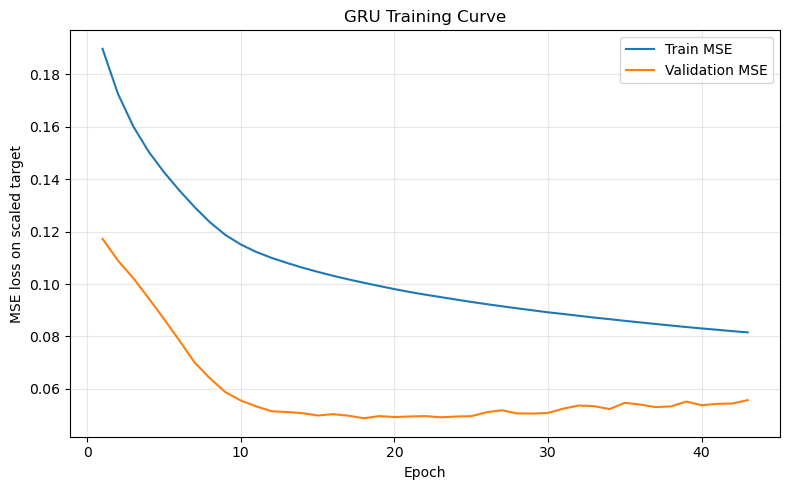

Saved figure to: outputs/problem3_correct_target/gru_A_core_L12_H16/gru_training_curve.png


In [12]:
# =========================
# 10.1 Plot training curve
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train MSE")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE loss on scaled target")
plt.title("GRU Training Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = OUTPUT_DIR / "gru_training_curve.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

## 11. Evaluate on test set

输出每个 horizon 的 MAE、RMSE、R²，以及整体指标。

In [13]:
# =========================
# 11. Evaluation
# =========================

def predict_loader(model, loader, device="cpu"):
    model.eval()
    preds, trues, masks = [], [], []

    with torch.no_grad():
        for xb, yb, mb in loader:
            xb = xb.to(device)
            preds.append(model(xb).cpu().numpy())
            trues.append(yb.numpy())
            masks.append(mb.numpy())

    return np.vstack(preds), np.vstack(trues), np.vstack(masks).astype(bool)

def inverse_target_scaled(arr_2d):
    original_shape = arr_2d.shape
    return target_scaler.inverse_transform(arr_2d.reshape(-1, 1)).reshape(original_shape)

def observed_regression_metrics(yt, yp):
    if len(yt) == 0:
        return np.nan, np.nan, np.nan
    mae = mean_absolute_error(yt, yp)
    rmse = math.sqrt(mean_squared_error(yt, yp))
    r2 = r2_score(yt, yp) if len(yt) >= 2 else np.nan
    return mae, rmse, r2

y_pred_scaled, y_true_scaled, y_observed_mask = predict_loader(model, test_loader, device)
y_pred = inverse_target_scaled(y_pred_scaled)
y_true = inverse_target_scaled(y_true_scaled)

metrics = []
for i, hour in enumerate(HORIZON_HOURS):
    valid = y_observed_mask[:, i]
    mae, rmse, r2 = observed_regression_metrics(y_true[valid, i], y_pred[valid, i])
    metrics.append({
        "horizon": f"t+{i+1}",
        "horizon_hour": hour,
        "observed_count": int(valid.sum()),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })

overall_valid = y_observed_mask.reshape(-1)
overall_true = y_true.reshape(-1)[overall_valid]
overall_pred = y_pred.reshape(-1)[overall_valid]
mae, rmse, r2 = observed_regression_metrics(overall_true, overall_pred)
metrics.append({
    "horizon": "overall",
    "horizon_hour": "2-12",
    "observed_count": int(overall_valid.sum()),
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
})

metrics_df = pd.DataFrame(metrics)
metrics_path = OUTPUT_DIR / "gru_test_metrics.xlsx"
metrics_df.to_excel(metrics_path, index=False)

display(metrics_df)
print("Metrics exclude originally missing target values.")
print("Saved metrics to:", metrics_path)


,horizon,horizon_hour,observed_count,MAE,RMSE,R2
0,t+1,2,466,0.037500,0.089284,0.783343
1,t+2,4,466,0.057118,0.110134,0.670425
2,t+3,6,466,0.067270,0.119515,0.612001
3,t+4,8,466,0.071959,0.118391,0.619489
4,t+5,10,466,0.071332,0.121308,0.600744
5,t+6,12,466,0.084619,0.132677,0.522974
6,overall,2-12,2796,0.064966,0.115989,0.634761


Metrics exclude originally missing target values.
Saved metrics to: outputs/problem3_correct_target/gru_A_core_L12_H16/gru_test_metrics.xlsx


In [14]:
# =========================
# 11.1 Build test prediction long table
# =========================

test_pred_rows = []
for sample_idx in range(len(y_pred)):
    for h_idx, hour in enumerate(HORIZON_HOURS):
        test_pred_rows.append({
            "base_time": pd.Timestamp(test_base_times[sample_idx]),
            "target_time": pd.Timestamp(test_target_times[sample_idx, h_idx]),
            "horizon_hour": hour,
            "target_observed": bool(y_observed_mask[sample_idx, h_idx]),
            "y_true": y_true[sample_idx, h_idx] if y_observed_mask[sample_idx, h_idx] else np.nan,
            "y_pred": y_pred[sample_idx, h_idx],
            "error": (y_pred[sample_idx, h_idx] - y_true[sample_idx, h_idx]) if y_observed_mask[sample_idx, h_idx] else np.nan,
            "abs_error": abs(y_pred[sample_idx, h_idx] - y_true[sample_idx, h_idx]) if y_observed_mask[sample_idx, h_idx] else np.nan,
        })

test_predictions_df = pd.DataFrame(test_pred_rows)
test_pred_path = OUTPUT_DIR / "gru_test_predictions_long.xlsx"
test_predictions_df.to_excel(test_pred_path, index=False)

display(test_predictions_df.head())
print("Saved test predictions to:", test_pred_path)

,base_time,target_time,horizon_hour,target_observed,y_true,y_pred,error,abs_error
0,2026-01-23 23:00:00,2026-01-24 01:00:00,2,True,0.28,0.263510,-0.016490,0.016490
1,2026-01-23 23:00:00,2026-01-24 03:00:00,4,True,0.27,0.305578,0.035578,0.035578
2,2026-01-23 23:00:00,2026-01-24 05:00:00,6,True,0.27,0.292130,0.022130,0.022130
3,2026-01-23 23:00:00,2026-01-24 07:00:00,8,True,0.27,0.342337,0.072337,0.072337
4,2026-01-23 23:00:00,2026-01-24 09:00:00,10,True,0.27,0.306861,0.036861,0.036861


Saved test predictions to: outputs/problem3_correct_target/gru_A_core_L12_H16/gru_test_predictions_long.xlsx


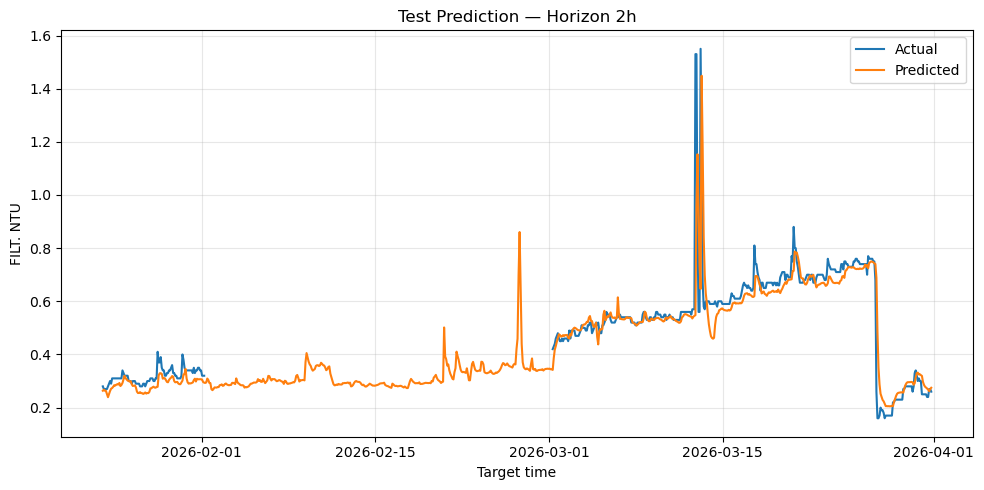

Saved figure to: outputs/problem3_correct_target/gru_A_core_L12_H16/test_prediction_horizon_2h.png


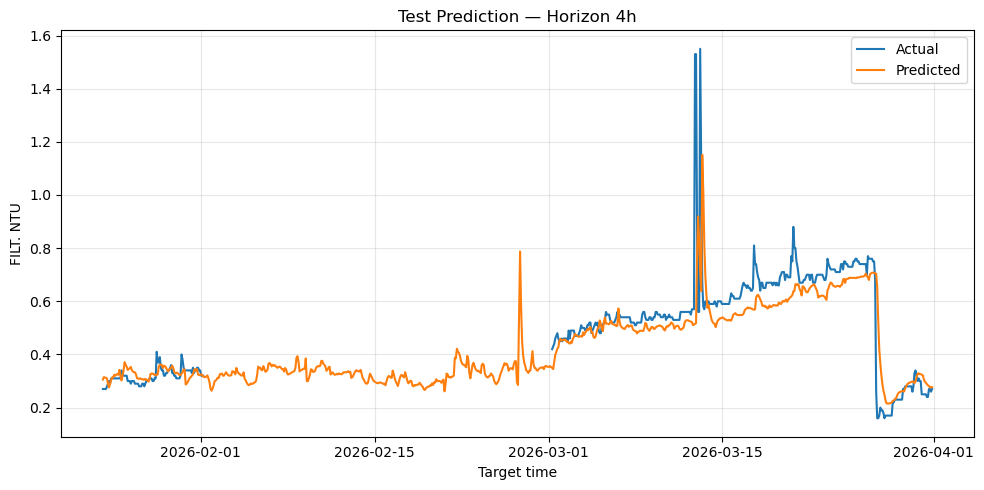

Saved figure to: outputs/problem3_correct_target/gru_A_core_L12_H16/test_prediction_horizon_4h.png


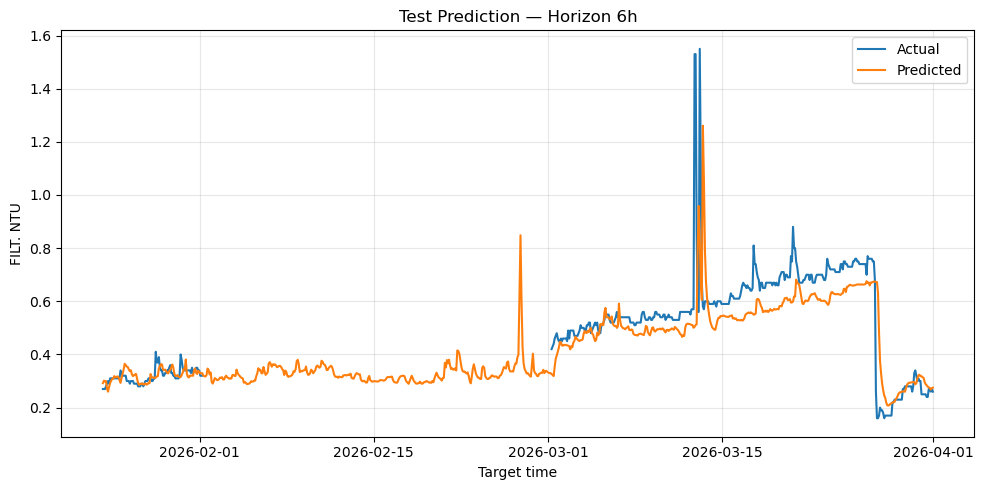

Saved figure to: outputs/problem3_correct_target/gru_A_core_L12_H16/test_prediction_horizon_6h.png


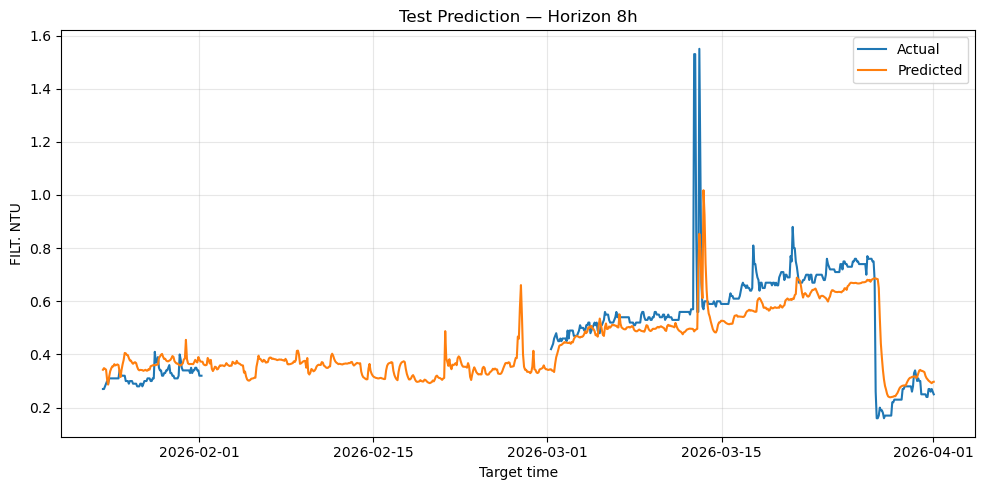

Saved figure to: outputs/problem3_correct_target/gru_A_core_L12_H16/test_prediction_horizon_8h.png


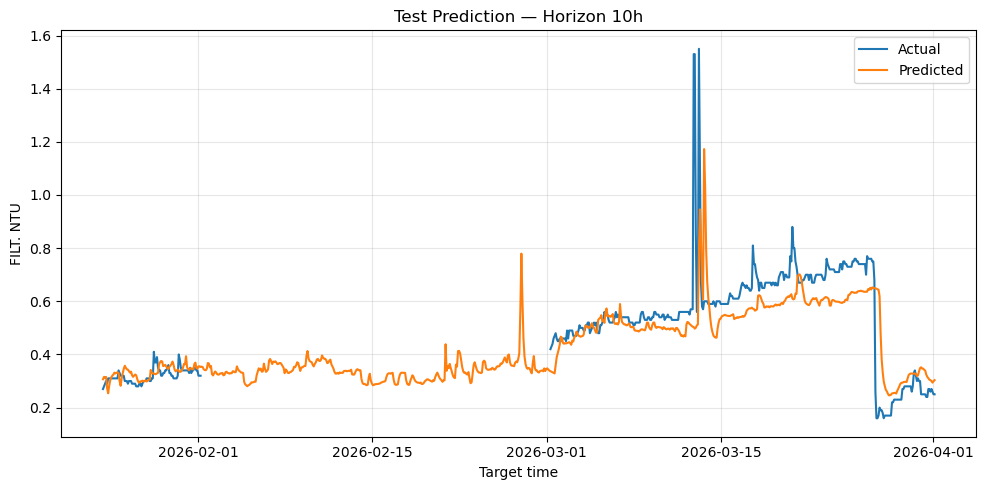

Saved figure to: outputs/problem3_correct_target/gru_A_core_L12_H16/test_prediction_horizon_10h.png


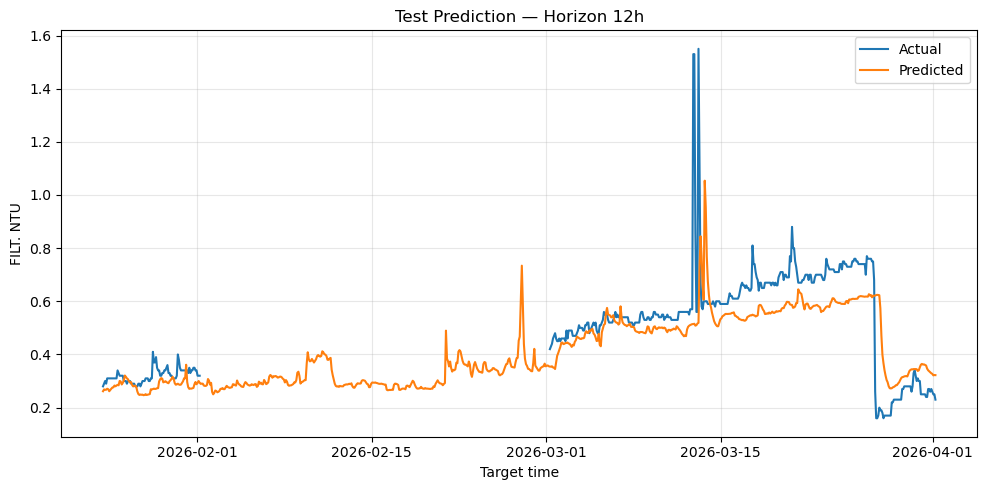

Saved figure to: outputs/problem3_correct_target/gru_A_core_L12_H16/test_prediction_horizon_12h.png


In [15]:
# =========================
# 11.2 Plot test predictions by horizon
# =========================

for h_idx, hour in enumerate(HORIZON_HOURS):
    plot_df = pd.DataFrame({
        "target_time": pd.to_datetime(test_target_times[:, h_idx]),
        "actual": np.where(y_observed_mask[:, h_idx], y_true[:, h_idx], np.nan),
        "predicted": y_pred[:, h_idx],
    }).sort_values("target_time")

    plt.figure(figsize=(10, 5))
    plt.plot(plot_df["target_time"], plot_df["actual"], label="Actual")
    plt.plot(plot_df["target_time"], plot_df["predicted"], label="Predicted")
    plt.xlabel("Target time")
    plt.ylabel("FILT. NTU")
    plt.title(f"Test Prediction — Horizon {hour}h")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    fig_path = OUTPUT_DIR / f"test_prediction_horizon_{hour}h.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved figure to:", fig_path)

## 12. Required dates prediction

题目要求：

```text
2026-02-01, 2026-02-10, 2026-02-20
07:00 至 19:00
```

由于原始数据是 2 小时采样，可能没有精确的奇数小时，如 `07:00, 09:00, ...`。

因此本 notebook 同时输出两类表：

1. **Exact requested-time table**  
   尝试输出题目给定的 `07:00, 09:00, ..., 19:00`。如果数据中没有对应预测起点，则保留 NaN 并写明原因，不报错。

2. **Native 2-hour grid table**  
   选择最接近且不晚于 `07:00` 的可用基准时刻，例如 `06:00`，然后输出模型原生的未来 2–12 小时预测，例如 `08:00–18:00`。这更符合 2 小时采样数据的实际预测能力。

In [16]:
# =========================
# 12. Prediction helper functions
# =========================

def get_time_position_map(df: pd.DataFrame):
    times = pd.to_datetime(df["DATETIME"]).dt.floor("min")
    return {t: i for i, t in enumerate(times)}

time_to_pos = get_time_position_map(full_df)

def is_continuous_time_window(times, expected_freq_hours=2):
    times = pd.to_datetime(pd.Series(times))
    diffs = times.diff().dropna()
    if len(diffs) == 0:
        return True
    return (diffs == pd.Timedelta(hours=expected_freq_hours)).all()

def predict_from_base_time(base_time, require_continuous=True, return_scaled=False):
    base_time = pd.Timestamp(base_time).floor("min")
    if base_time not in time_to_pos:
        return {
            "ok": False,
            "reason": f"base_time not found: {base_time}",
            "base_time": base_time,
        }

    pos = time_to_pos[base_time]
    start_pos = pos - LOOKBACK + 1
    end_pos = pos

    if start_pos < 0:
        return {
            "ok": False,
            "reason": f"not enough lookback history before {base_time}",
            "base_time": base_time,
        }

    history_times = pd.to_datetime(full_df.iloc[start_pos:end_pos + 1]["DATETIME"]).dt.floor("min").tolist()
    if require_continuous and not is_continuous_time_window(history_times, EXPECTED_FREQ_HOURS):
        return {
            "ok": False,
            "reason": f"history window is not continuous before {base_time}",
            "base_time": base_time,
        }

    x = full_scaled.iloc[start_pos:end_pos + 1][FEATURES].to_numpy(dtype=np.float32)
    x_tensor = torch.tensor(x[None, :, :], dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        pred_scaled = model(x_tensor).cpu().numpy()

    pred = inverse_target_scaled(pred_scaled)[0]
    future_times = [base_time + pd.Timedelta(hours=h) for h in HORIZON_HOURS]

    return {
        "ok": True,
        "reason": "",
        "base_time": base_time,
        "future_times": future_times,
        "horizon_hours": HORIZON_HOURS,
        "predictions": pred,
        "predictions_scaled": pred_scaled[0] if return_scaled else None,
    }

def safe_pivot_time_table(df, index_col, time_col, value_col, expected_index_values, expected_times):
    """
    Pivot without KeyError even when all predictions are NaN.
    """
    if len(df) == 0:
        pivot = pd.DataFrame({index_col: expected_index_values})
    else:
        valid_for_pivot = df.copy()
        pivot = valid_for_pivot.pivot_table(
            index=index_col,
            columns=time_col,
            values=value_col,
            aggfunc="first",
        ).reset_index()
        pivot.columns.name = None

    if index_col not in pivot.columns:
        pivot = pd.DataFrame({index_col: expected_index_values})

    for idx_value in expected_index_values:
        if idx_value not in set(pivot[index_col].astype(str)):
            extra = pd.DataFrame({index_col: [idx_value]})
            pivot = pd.concat([pivot, extra], ignore_index=True)

    for t in expected_times:
        if t not in pivot.columns:
            pivot[t] = np.nan

    pivot[index_col] = pivot[index_col].astype(str)
    pivot = pivot[[index_col] + expected_times]
    pivot = pivot.sort_values(index_col).reset_index(drop=True)
    return pivot

def choose_native_base_time(date_str, desired_time="07:00", tolerance_hours=1.1):
    """
    Choose the nearest available base time not later than desired_time within the same date.
    Example: if desired is 07:00 and available grid is 00,02,04,06,08,..., choose 06:00.
    """
    desired = pd.Timestamp(f"{date_str} {desired_time}")
    all_times = pd.to_datetime(full_df["DATETIME"]).dt.floor("min")
    same_date = all_times[all_times.dt.date == desired.date()]

    if len(same_date) == 0:
        return None, f"no timestamps found on {date_str}"

    past_or_equal = same_date[same_date <= desired]
    if len(past_or_equal) > 0:
        candidate = past_or_equal.max()
        delta_hours = abs((desired - candidate).total_seconds()) / 3600
        if delta_hours <= tolerance_hours:
            return candidate, f"chosen latest available time not later than {desired_time}"

    # Fallback: nearest available time within tolerance.
    deltas = (same_date - desired).abs()
    nearest_idx = deltas.idxmin()
    candidate = same_date.loc[nearest_idx]
    delta_hours = abs((candidate - desired).total_seconds()) / 3600
    if delta_hours <= tolerance_hours:
        return candidate, f"chosen nearest available time to {desired_time}"

    return None, f"no available base time within {tolerance_hours}h of {desired}"

In [17]:
# =========================
# 12.1 Exact requested-time table
# =========================

def build_exact_requested_prediction_table():
    rows = []

    for date_str in REQUESTED_DATES:
        # 07:00 is predicted from 05:00 with horizon 2h.
        target_0700 = pd.Timestamp(f"{date_str} 07:00")
        base_0500 = target_0700 - pd.Timedelta(hours=2)
        result_0700 = predict_from_base_time(base_0500, require_continuous=(sequence_mode == "gap_aware"))

        if result_0700["ok"]:
            rows.append({
                "date": date_str,
                "target_time": target_0700,
                "time": "07:00",
                "prediction_FILT_NTU": result_0700["predictions"][0],
                "base_time": result_0700["base_time"],
                "horizon_hour": 2,
                "status": "ok",
                "note": "07:00 predicted from 05:00 using 2h horizon",
            })
        else:
            rows.append({
                "date": date_str,
                "target_time": target_0700,
                "time": "07:00",
                "prediction_FILT_NTU": np.nan,
                "base_time": base_0500,
                "horizon_hour": 2,
                "status": "missing",
                "note": result_0700["reason"],
            })

        # 09:00–19:00 are predicted from 07:00 with direct multi-step output.
        base_0700 = pd.Timestamp(f"{date_str} 07:00")
        result = predict_from_base_time(base_0700, require_continuous=(sequence_mode == "gap_aware"))

        if result["ok"]:
            for future_time, hour, pred in zip(result["future_times"], result["horizon_hours"], result["predictions"]):
                time_label = future_time.strftime("%H:%M")
                if time_label in REQUESTED_TIMES:
                    rows.append({
                        "date": date_str,
                        "target_time": future_time,
                        "time": time_label,
                        "prediction_FILT_NTU": pred,
                        "base_time": result["base_time"],
                        "horizon_hour": hour,
                        "status": "ok",
                        "note": "Predicted from exact 07:00 using direct multi-step output",
                    })
        else:
            for time_str in REQUESTED_TIMES[1:]:
                target_time = pd.Timestamp(f"{date_str} {time_str}")
                rows.append({
                    "date": date_str,
                    "target_time": target_time,
                    "time": time_str,
                    "prediction_FILT_NTU": np.nan,
                    "base_time": base_0700,
                    "horizon_hour": int((target_time - base_0700).total_seconds() // 3600),
                    "status": "missing",
                    "note": result["reason"],
                })

    out = pd.DataFrame(rows)
    out = out.sort_values(["date", "target_time"]).reset_index(drop=True)
    return out

required_exact_df = build_exact_requested_prediction_table()

required_exact_pivot_df = safe_pivot_time_table(
    required_exact_df,
    index_col="date",
    time_col="time",
    value_col="prediction_FILT_NTU",
    expected_index_values=REQUESTED_DATES,
    expected_times=REQUESTED_TIMES,
)

display(required_exact_df[["date", "time", "base_time", "status", "note"]])
display(required_exact_pivot_df)

,date,time,base_time,status,note
0,2026-02-01,07:00,2026-02-01 05:00:00,ok,07:00 predicted from 05:00 using 2h horizon
1,2026-02-01,09:00,2026-02-01 07:00:00,ok,Predicted from exact 07:00 using direct multi-...
2,2026-02-01,11:00,2026-02-01 07:00:00,ok,Predicted from exact 07:00 using direct multi-...
3,2026-02-01,13:00,2026-02-01 07:00:00,ok,Predicted from exact 07:00 using direct multi-...
4,2026-02-01,15:00,2026-02-01 07:00:00,ok,Predicted from exact 07:00 using direct multi-...
5,2026-02-01,17:00,2026-02-01 07:00:00,ok,Predicted from exact 07:00 using direct multi-...
6,2026-02-01,19:00,2026-02-01 07:00:00,ok,Predicted from exact 07:00 using direct multi-...
7,2026-02-10,07:00,2026-02-10 05:00:00,ok,07:00 predicted from 05:00 using 2h horizon
8,2026-02-10,09:00,2026-02-10 07:00:00,ok,Predicted from exact 07:00 using direct multi-...
9,2026-02-10,11:00,2026-02-10 07:00:00,ok,Predicted from exact 07:00 using direct multi-...


,date,07:00,09:00,11:00,13:00,15:00,17:00,19:00
0,2026-02-01,0.292796,0.294644,0.317173,0.322057,0.361083,0.345818,0.285075
1,2026-02-10,0.359332,0.359500,0.356059,0.352909,0.361508,0.376863,0.393884
2,2026-02-20,0.292773,0.295773,0.300963,0.311082,0.309340,0.302503,0.289244


In [18]:
# =========================
# 12.2 Native 2-hour grid prediction table
# =========================

def build_native_grid_prediction_table():
    rows = []

    for date_str in REQUESTED_DATES:
        base_time, base_note = choose_native_base_time(
            date_str,
            desired_time=NATIVE_GRID_START_TIME,
            tolerance_hours=NATIVE_BASE_TOLERANCE_HOURS,
        )

        if base_time is None:
            rows.append({
                "date": date_str,
                "base_time": pd.NaT,
                "target_time": pd.NaT,
                "time": None,
                "horizon_hour": np.nan,
                "prediction_FILT_NTU": np.nan,
                "status": "missing",
                "note": base_note,
            })
            continue

        result = predict_from_base_time(base_time, require_continuous=(sequence_mode == "gap_aware"))

        if result["ok"]:
            for future_time, hour, pred in zip(result["future_times"], result["horizon_hours"], result["predictions"]):
                rows.append({
                    "date": date_str,
                    "base_time": result["base_time"],
                    "target_time": future_time,
                    "time": future_time.strftime("%H:%M"),
                    "horizon_hour": hour,
                    "prediction_FILT_NTU": pred,
                    "status": "ok",
                    "note": base_note + "; native 2-hour grid output",
                })
        else:
            rows.append({
                "date": date_str,
                "base_time": base_time,
                "target_time": pd.NaT,
                "time": None,
                "horizon_hour": np.nan,
                "prediction_FILT_NTU": np.nan,
                "status": "missing",
                "note": result["reason"],
            })

    out = pd.DataFrame(rows)
    out = out.sort_values(["date", "target_time"]).reset_index(drop=True)
    return out

native_grid_df = build_native_grid_prediction_table()

native_times = sorted([t for t in native_grid_df["time"].dropna().unique().tolist()])
native_grid_pivot_df = safe_pivot_time_table(
    native_grid_df.dropna(subset=["time"]),
    index_col="date",
    time_col="time",
    value_col="prediction_FILT_NTU",
    expected_index_values=REQUESTED_DATES,
    expected_times=native_times,
)

display(native_grid_df[["date", "base_time", "target_time", "time", "horizon_hour", "prediction_FILT_NTU", "status", "note"]])
display(native_grid_pivot_df)

required_path = OUTPUT_DIR / "required_dates_predictions.xlsx"
with pd.ExcelWriter(required_path) as writer:
    required_exact_df.to_excel(writer, sheet_name="exact_requested_long", index=False)
    required_exact_pivot_df.to_excel(writer, sheet_name="exact_requested_pivot", index=False)
    native_grid_df.to_excel(writer, sheet_name="native_2h_grid_long", index=False)
    native_grid_pivot_df.to_excel(writer, sheet_name="native_2h_grid_pivot", index=False)

print("Saved required/native-grid predictions to:", required_path)

,date,base_time,target_time,time,horizon_hour,prediction_FILT_NTU,status,note
0,2026-02-01,2026-02-01 07:00:00,2026-02-01 09:00:00,09:00,2,0.294644,ok,chosen latest available time not later than 07...
1,2026-02-01,2026-02-01 07:00:00,2026-02-01 11:00:00,11:00,4,0.317173,ok,chosen latest available time not later than 07...
2,2026-02-01,2026-02-01 07:00:00,2026-02-01 13:00:00,13:00,6,0.322057,ok,chosen latest available time not later than 07...
3,2026-02-01,2026-02-01 07:00:00,2026-02-01 15:00:00,15:00,8,0.361083,ok,chosen latest available time not later than 07...
4,2026-02-01,2026-02-01 07:00:00,2026-02-01 17:00:00,17:00,10,0.345818,ok,chosen latest available time not later than 07...
5,2026-02-01,2026-02-01 07:00:00,2026-02-01 19:00:00,19:00,12,0.285075,ok,chosen latest available time not later than 07...
6,2026-02-10,2026-02-10 07:00:00,2026-02-10 09:00:00,09:00,2,0.359500,ok,chosen latest available time not later than 07...
7,2026-02-10,2026-02-10 07:00:00,2026-02-10 11:00:00,11:00,4,0.356059,ok,chosen latest available time not later than 07...
8,2026-02-10,2026-02-10 07:00:00,2026-02-10 13:00:00,13:00,6,0.352909,ok,chosen latest available time not later than 07...
9,2026-02-10,2026-02-10 07:00:00,2026-02-10 15:00:00,15:00,8,0.361508,ok,chosen latest available time not later than 07...


,date,09:00,11:00,13:00,15:00,17:00,19:00
0,2026-02-01,0.294644,0.317173,0.322057,0.361083,0.345818,0.285075
1,2026-02-10,0.359500,0.356059,0.352909,0.361508,0.376863,0.393884
2,2026-02-20,0.295773,0.300963,0.311082,0.309340,0.302503,0.289244


Saved required/native-grid predictions to: outputs/problem3_correct_target/gru_A_core_L12_H16/required_dates_predictions.xlsx


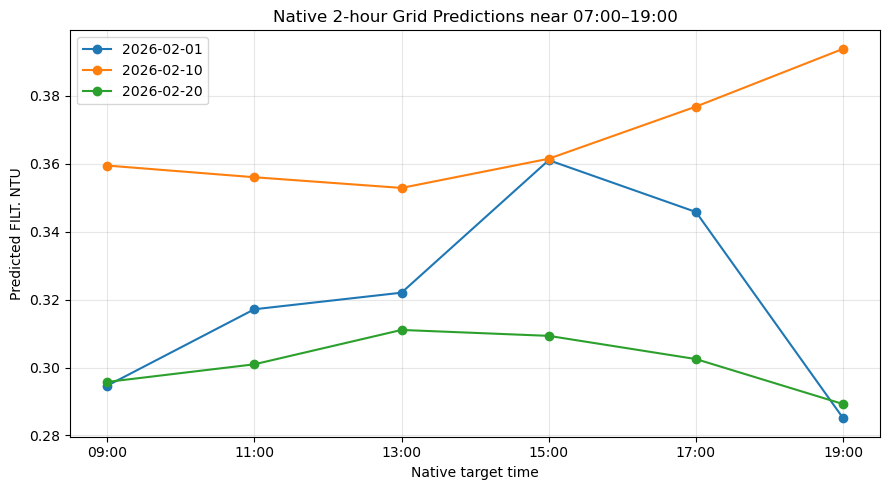

Saved figure to: outputs/problem3_correct_target/gru_A_core_L12_H16/native_grid_predictions.png


In [19]:
# =========================
# 12.3 Plot native-grid predictions
# =========================

plot_native = native_grid_df.query("status == 'ok'").dropna(subset=["prediction_FILT_NTU"]).copy()

if len(plot_native) > 0:
    plt.figure(figsize=(9, 5))
    for date_str, group in plot_native.groupby("date"):
        group = group.sort_values("target_time")
        plt.plot(group["time"], group["prediction_FILT_NTU"], marker="o", label=date_str)

    plt.xlabel("Native target time")
    plt.ylabel("Predicted FILT. NTU")
    plt.title("Native 2-hour Grid Predictions near 07:00–19:00")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    fig_path = OUTPUT_DIR / "native_grid_predictions.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved figure to:", fig_path)
else:
    print("No native-grid predictions available to plot.")

## 13. Sensitivity analysis

题目要求分析不同输入变量对预测结果的敏感性，尤其是：

- 原水水质突变：`R/W NTU`
- 矾投加调整：`AL_DOSE`

Baseline 做法：

在保持其他变量不变的情况下，对预测基准时刻附近最后一个输入点进行比例扰动：

```text
-20%, -10%, baseline, +10%, +20%
```

然后观察未来 2–12 小时 `FILT. NTU` 预测变化。

In [20]:
# =========================
# 13. Sensitivity analysis
# =========================

SENSITIVITY_VARIABLES = ["R/W NTU", "AL_DOSE"]
SENSITIVITY_FACTORS = [0.80, 0.90, 1.00, 1.10, 1.20]

def predict_from_base_with_perturbation(
    base_time,
    perturb_variable=None,
    factor=1.0,
    perturb_last_k=1,
    require_continuous=True,
):
    base_time = pd.Timestamp(base_time).floor("min")

    if base_time not in time_to_pos:
        return {
            "ok": False,
            "reason": f"base_time not found: {base_time}",
            "base_time": base_time,
        }

    pos = time_to_pos[base_time]
    start_pos = pos - LOOKBACK + 1
    end_pos = pos

    if start_pos < 0:
        return {
            "ok": False,
            "reason": f"not enough lookback history before {base_time}",
            "base_time": base_time,
        }

    history_raw = full_df.iloc[start_pos:end_pos + 1].copy()
    history_times = pd.to_datetime(history_raw["DATETIME"]).dt.floor("min").tolist()

    if require_continuous and not is_continuous_time_window(history_times, EXPECTED_FREQ_HOURS):
        return {
            "ok": False,
            "reason": f"history window is not continuous before {base_time}",
            "base_time": base_time,
        }

    if perturb_variable is not None and perturb_variable in FEATURES:
        idx_start = max(0, len(history_raw) - perturb_last_k)
        rows_to_perturb = history_raw.index[idx_start:]

        # Fix for pandas 2.x:
        # Some variables may be stored as int64. Multiplying by 0.8 or 1.2
        # produces float values such as 9.6, which cannot be safely assigned
        # back into an int64 column. Cast the perturbed column to float first.
        history_raw[perturb_variable] = history_raw[perturb_variable].astype(float)
        history_raw.loc[rows_to_perturb, perturb_variable] = (
            history_raw.loc[rows_to_perturb, perturb_variable].astype(float) * float(factor)
        )
    elif perturb_variable is not None:
        return {
            "ok": False,
            "reason": f"perturb_variable not in FEATURES: {perturb_variable}",
            "base_time": base_time,
        }

    x_scaled = feature_scaler.transform(history_raw[FEATURES]).astype(np.float32)
    x_tensor = torch.tensor(x_scaled[None, :, :], dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        pred_scaled = model(x_tensor).cpu().numpy()

    pred = inverse_target_scaled(pred_scaled)[0]

    return {
        "ok": True,
        "reason": "",
        "base_time": base_time,
        "future_times": [base_time + pd.Timedelta(hours=h) for h in HORIZON_HOURS],
        "horizon_hours": HORIZON_HOURS,
        "predictions": pred,
    }

def run_sensitivity_analysis():
    rows = []

    for date_str in REQUESTED_DATES:
        base_time, base_note = choose_native_base_time(
            date_str,
            desired_time=NATIVE_GRID_START_TIME,
            tolerance_hours=NATIVE_BASE_TOLERANCE_HOURS,
        )

        if base_time is None:
            rows.append({
                "date": date_str,
                "base_time": pd.NaT,
                "variable": "ALL",
                "factor": np.nan,
                "scenario": "missing",
                "horizon_hour": np.nan,
                "target_time": pd.NaT,
                "prediction_FILT_NTU": np.nan,
                "baseline_prediction": np.nan,
                "change_abs": np.nan,
                "change_pct": np.nan,
                "status": "missing",
                "note": base_note,
            })
            continue

        baseline_result = predict_from_base_with_perturbation(
            base_time,
            perturb_variable=None,
            factor=1.0,
            require_continuous=(sequence_mode == "gap_aware"),
        )

        if not baseline_result["ok"]:
            rows.append({
                "date": date_str,
                "base_time": base_time,
                "variable": "ALL",
                "factor": np.nan,
                "scenario": "missing",
                "horizon_hour": np.nan,
                "target_time": pd.NaT,
                "prediction_FILT_NTU": np.nan,
                "baseline_prediction": np.nan,
                "change_abs": np.nan,
                "change_pct": np.nan,
                "status": "missing",
                "note": baseline_result["reason"],
            })
            continue

        baseline_pred = np.array(baseline_result["predictions"])

        for var in SENSITIVITY_VARIABLES:
            for factor in SENSITIVITY_FACTORS:
                result = predict_from_base_with_perturbation(
                    base_time,
                    perturb_variable=var,
                    factor=factor,
                    perturb_last_k=1,
                    require_continuous=(sequence_mode == "gap_aware"),
                )

                if result["ok"]:
                    pred = np.array(result["predictions"])
                    for i, hour in enumerate(HORIZON_HOURS):
                        change_abs = pred[i] - baseline_pred[i]
                        change_pct = change_abs / (abs(baseline_pred[i]) + 1e-8) * 100

                        rows.append({
                            "date": date_str,
                            "base_time": base_time,
                            "variable": var,
                            "factor": factor,
                            "scenario": f"{var} x {factor:.2f}",
                            "horizon_hour": hour,
                            "target_time": base_time + pd.Timedelta(hours=hour),
                            "prediction_FILT_NTU": pred[i],
                            "baseline_prediction": baseline_pred[i],
                            "change_abs": change_abs,
                            "change_pct": change_pct,
                            "status": "ok",
                            "note": base_note + "; perturb last input step",
                        })
                else:
                    rows.append({
                        "date": date_str,
                        "base_time": base_time,
                        "variable": var,
                        "factor": factor,
                        "scenario": f"{var} x {factor:.2f}",
                        "horizon_hour": np.nan,
                        "target_time": pd.NaT,
                        "prediction_FILT_NTU": np.nan,
                        "baseline_prediction": np.nan,
                        "change_abs": np.nan,
                        "change_pct": np.nan,
                        "status": "missing",
                        "note": result["reason"],
                    })

    return pd.DataFrame(rows)

sensitivity_df = run_sensitivity_analysis()

sensitivity_path = OUTPUT_DIR / "sensitivity_analysis.xlsx"
sensitivity_df.to_excel(sensitivity_path, index=False)

display(sensitivity_df.head(30))
print("Saved sensitivity analysis to:", sensitivity_path)

,date,base_time,variable,factor,scenario,horizon_hour,target_time,prediction_FILT_NTU,baseline_prediction,change_abs,change_pct,status,note
0,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.8,R/W NTU x 0.80,2,2026-02-01 09:00:00,0.295640,0.294644,0.000996,0.338185,ok,chosen latest available time not later than 07...
1,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.8,R/W NTU x 0.80,4,2026-02-01 11:00:00,0.316955,0.317173,-0.000218,-0.068611,ok,chosen latest available time not later than 07...
2,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.8,R/W NTU x 0.80,6,2026-02-01 13:00:00,0.321026,0.322057,-0.001031,-0.320151,ok,chosen latest available time not later than 07...
3,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.8,R/W NTU x 0.80,8,2026-02-01 15:00:00,0.360501,0.361083,-0.000582,-0.161094,ok,chosen latest available time not later than 07...
4,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.8,R/W NTU x 0.80,10,2026-02-01 17:00:00,0.345972,0.345818,0.000154,0.044589,ok,chosen latest available time not later than 07...
5,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.8,R/W NTU x 0.80,12,2026-02-01 19:00:00,0.285516,0.285075,0.000442,0.154963,ok,chosen latest available time not later than 07...
6,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.9,R/W NTU x 0.90,2,2026-02-01 09:00:00,0.295133,0.294644,0.000490,0.166195,ok,chosen latest available time not later than 07...
7,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.9,R/W NTU x 0.90,4,2026-02-01 11:00:00,0.317066,0.317173,-0.000107,-0.033780,ok,chosen latest available time not later than 07...
8,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.9,R/W NTU x 0.90,6,2026-02-01 13:00:00,0.321537,0.322057,-0.000520,-0.161515,ok,chosen latest available time not later than 07...
9,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.9,R/W NTU x 0.90,8,2026-02-01 15:00:00,0.360792,0.361083,-0.000290,-0.080431,ok,chosen latest available time not later than 07...


Saved sensitivity analysis to: outputs/problem3_correct_target/gru_A_core_L12_H16/sensitivity_analysis.xlsx


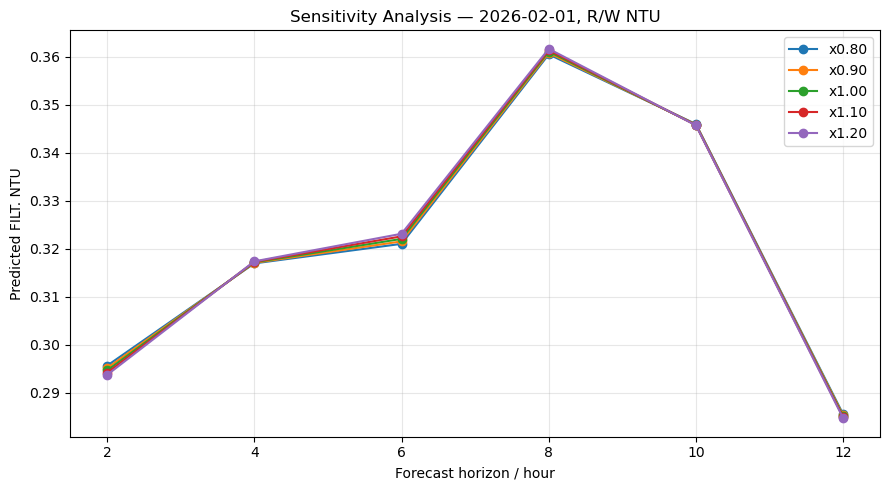

Saved figure to: outputs/problem3_correct_target/gru_A_core_L12_H16/sensitivity_2026-02-01_RW_NTU.png


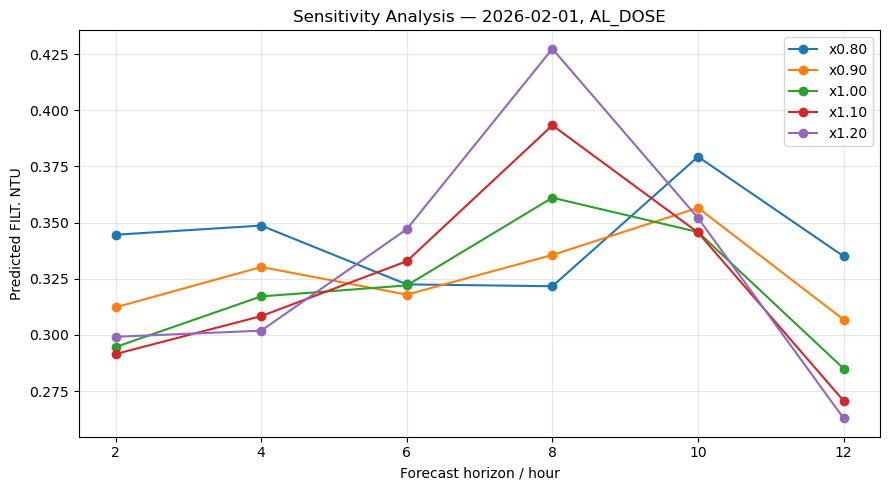

Saved figure to: outputs/problem3_correct_target/gru_A_core_L12_H16/sensitivity_2026-02-01_AL_DOSE.png


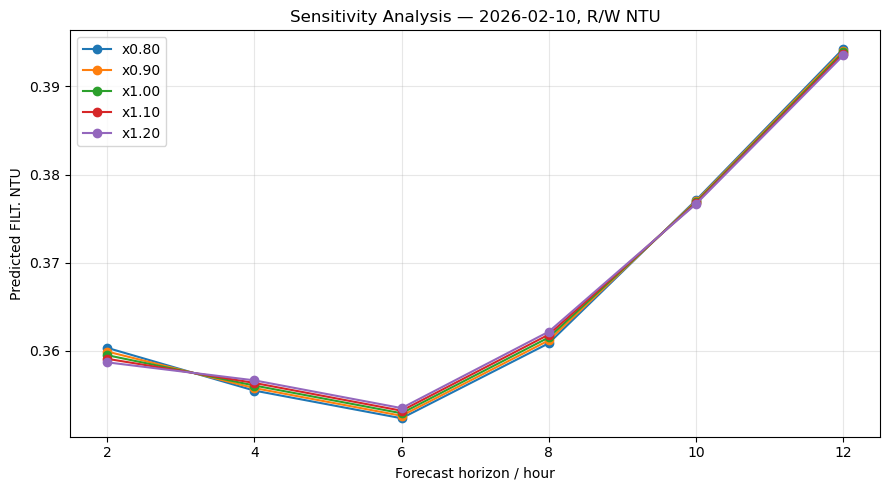

Saved figure to: outputs/problem3_correct_target/gru_A_core_L12_H16/sensitivity_2026-02-10_RW_NTU.png


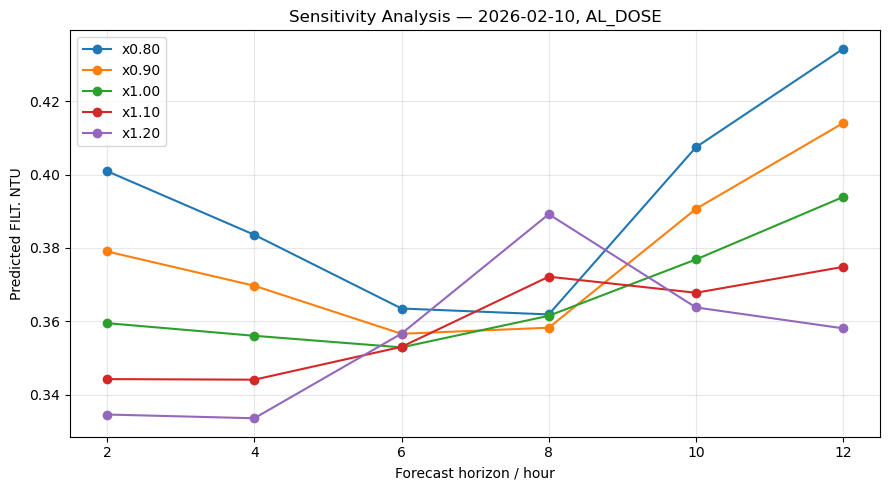

Saved figure to: outputs/problem3_correct_target/gru_A_core_L12_H16/sensitivity_2026-02-10_AL_DOSE.png


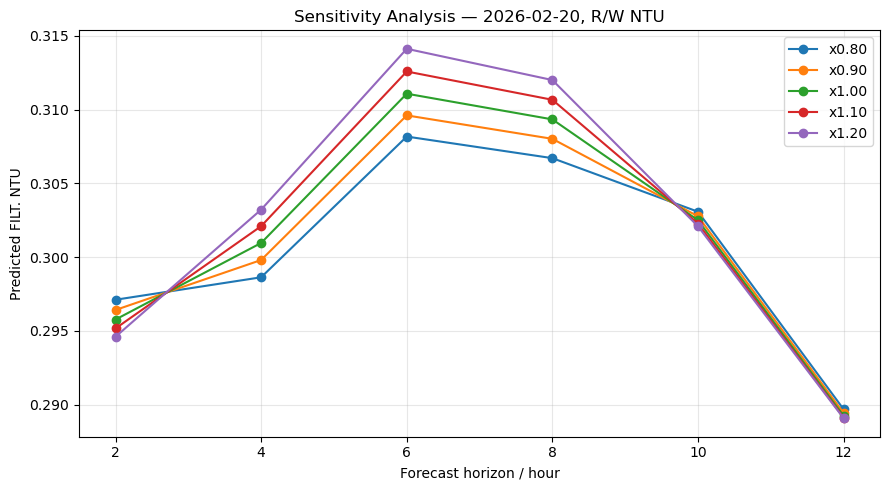

Saved figure to: outputs/problem3_correct_target/gru_A_core_L12_H16/sensitivity_2026-02-20_RW_NTU.png


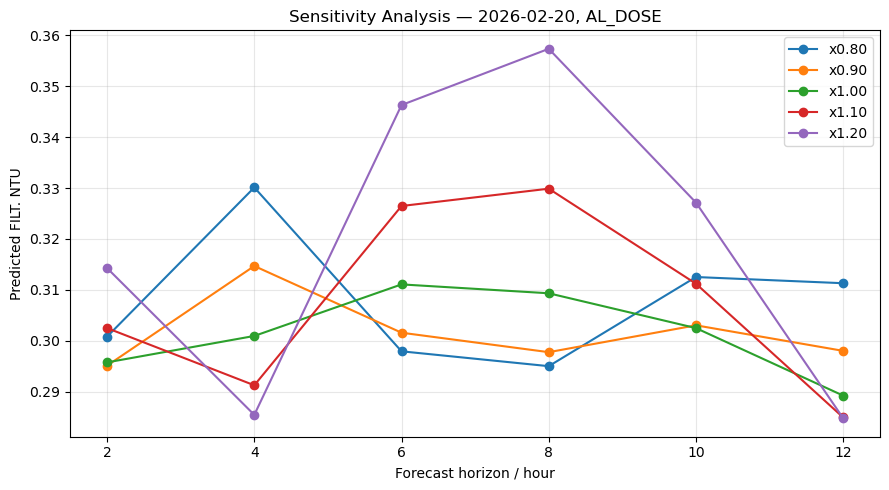

Saved figure to: outputs/problem3_correct_target/gru_A_core_L12_H16/sensitivity_2026-02-20_AL_DOSE.png


In [21]:
# =========================
# 13.1 Plot sensitivity curves
# =========================

available_sens = sensitivity_df.query("status == 'ok'").copy()

if len(available_sens) > 0:
    for date_str in REQUESTED_DATES:
        for var in SENSITIVITY_VARIABLES:
            plot_df = available_sens[
                (available_sens["date"] == date_str) &
                (available_sens["variable"] == var)
            ].copy()

            if len(plot_df) == 0:
                continue

            plt.figure(figsize=(9, 5))
            for factor, group in plot_df.groupby("factor"):
                group = group.sort_values("horizon_hour")
                plt.plot(
                    group["horizon_hour"],
                    group["prediction_FILT_NTU"],
                    marker="o",
                    label=f"x{factor:.2f}",
                )

            plt.xlabel("Forecast horizon / hour")
            plt.ylabel("Predicted FILT. NTU")
            plt.title(f"Sensitivity Analysis — {date_str}, {var}")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()

            safe_var = var.replace("/", "").replace(" ", "_")
            fig_path = OUTPUT_DIR / f"sensitivity_{date_str}_{safe_var}.png"
            plt.savefig(fig_path, dpi=300)
            plt.show()

            print("Saved figure to:", fig_path)
else:
    print("No available sensitivity results to plot.")

## 14. Export integrated Excel results

整合输出：

- `metrics`
- `test_predictions_long`
- `exact_requested_long`
- `exact_requested_pivot`
- `native_grid_long`
- `native_grid_pivot`
- `sensitivity_analysis`
- `training_history`

In [22]:
# =========================
# 14. Integrated export
# =========================

integrated_path = OUTPUT_DIR / "problem3_correct_target_gru_A_core_L12_H16_all_results.xlsx"

with pd.ExcelWriter(integrated_path) as writer:
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)
    test_predictions_df.to_excel(writer, sheet_name="test_predictions_long", index=False)
    required_exact_df.to_excel(writer, sheet_name="exact_requested_long", index=False)
    required_exact_pivot_df.to_excel(writer, sheet_name="exact_requested_pivot", index=False)
    native_grid_df.to_excel(writer, sheet_name="native_grid_long", index=False)
    native_grid_pivot_df.to_excel(writer, sheet_name="native_grid_pivot", index=False)
    sensitivity_df.to_excel(writer, sheet_name="sensitivity", index=False)
    history_df.to_excel(writer, sheet_name="training_history", index=False)

print("Saved integrated results to:", integrated_path)
print("Done.")

Saved integrated results to: outputs/problem3_correct_target/gru_A_core_L12_H16/problem3_correct_target_gru_A_core_L12_H16_all_results.xlsx
Done.


## 15. Suggested method description for the report

当前 notebook 是问题 3 的正确 target 版本，预测对象为 **出厂水浊度 NTU**，即清水/处理后水浊度列，不是 `FILT. NTU`。

英文：

> Since the original data were recorded every two hours, the future 1–12 hour forecasting task was discretized into a six-step forecasting problem, corresponding to 2, 4, 6, 8, 10 and 12 hours ahead. A pure direct multi-step GRU baseline was constructed to forecast the treated/outlet water turbidity NTU. The input sequence consists of historical raw-water quality, operating variables, filtered-water turbidity, storage/flow variables when available, and historical treated-water turbidity. The dataset was split chronologically into training, validation and testing blocks, and the scalers were fitted using the training block only to avoid temporal leakage.

中文：

> 由于原始数据的采样间隔为 2 小时，本文将未来 1–12 小时出厂水浊度预测任务离散化为未来 2、4、6、8、10、12 小时的六步预测问题。本文构建纯直接多步 GRU 基线模型，以历史原水水质、工艺运行变量、滤后水浊度、清水池/送水相关变量以及历史出厂水浊度为输入，直接预测未来多步出厂水浊度 NTU。数据集按照时间顺序划分为训练集、验证集和测试集，且所有标准化参数仅由训练集估计，以避免时间泄漏。

本配置：

```text
A_core_L12_H16
FEATURE_SET_MODE=core, LOOKBACK=12, HIDDEN_SIZE=16
```